# Reto de Inteligencia Artificial

Nombres: Fernanda Rodríguez, José Melej, Gustavo Salazar, Nicolás Montalvo


#Índice

1. Objetivo
2. Librerías
3. Carga de datos
4. Análisis de datos
    1. Estructura de los datos
    2. Información del dataset
    3. Distribución y correlación
5. Limpieza de datos
    1. Consumo en órdenes
    2. Saturación por semana
    3. Tiempos, repartos y post-entrega
6. Featuring Engineering  
    1. Cambio 1 — Variables de Batching
    2. Cambio 2 — Demanda en tiempo real   
    3. Cambio 3 — Variables de calendario, distancia e ítems
    4. Cambio 4 — Franja horaria (time_slot)
    5. Análisis de matriz de correlación con nuevas variables
7. Preprocesamiento de la data - Entrenamiento
    1. Pipeline de preprocesamiento
    2. División Train/Test
8. Modelado
    1. Entrenamiento de modelos
        1. Modelo 1 — Regresión Lineal (Baseline)
        2. Modelo 2 — XGBoost
        3. Modelo 3 — Random Forest
        4. Modelo 4 — LightGBM
        5. Modelos entrenados con Saturación
    2. Cross-Validation — Comparativa de los 4 modelos
    3. Importancia de features — Modelo ganador
    4. Modelización agregada
        1. Predicción por Intervalo de Confianza (Predicción Conforme)
        2. Evaluación estratificada por franja horaria
    5. Modelo con saturación
        1. Modelos con saturación directa
        2. Cross-Validation del modelo LightGBM (v2)
        3. Importancia de Features del modelo LightGBM (v2)
9. Conclusiones
    1. Conclusiones generales
    2. Resumen de Modelos con Features v2 y Comparativa
10. Recomendaciones




# 1. Objetivo

**Proveer un modelo de aprendizaje automático para obtener un ETA**

<h6>ETA: Estimated Time Arrival</h6>

# 2. Librerías

In [ ]:
import pandas as pd
import numpy as np
import math
import re
import warnings
warnings.filterwarnings('ignore')
!pip install lightgbm xgboost plotly seaborn -q

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

# 3. Carga de datos

In [ ]:
csv = 'https://huggingface.co/datasets/gsv24/glovo-ops/resolve/main/glovo_ops_data_final.csv'

ds = pd.read_csv(filepath_or_buffer=csv, engine='c')
df = ds.copy()

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 63,646 filas × 21 columnas


# 4. Análisis de los datos


## 4.1. Estructura de los datos

In [ ]:
df.tail()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
63641,51602.0,1297295,92.0,60709.0,Aux Merveilleux de Fred,WALL - NonPartner,30.3,6.9,2 x L’ Impensable - Mini\n2 x Le Merveilleux ...,2019-11-23 10:28:51.000,...,2019-11-23 11:04:19.883,2019-11-23 11:20:22.000,MOTORBIKE,NaN,NaN,48.844928,2.237055,48.819739,2.257546,96
63642,814.0,20092243,97.0,13198.0,Benson Kfé,WALL - Partner,21.9,3.9,1 x Chicken,2019-10-02 12:00:35.000,...,2019-10-02 12:12:21.561,2019-10-02 12:37:06.000,MOTORBIKE,NaN,NaN,48.878383,2.285877,48.892718,2.238183,103
63643,81638.0,6234499,59.0,NaN,NaN,COURIER,11.9,11.9,Une livraison à 15h au 1 TER CITÉ GERMAIN PILO...,2019-12-25 13:39:32.000,...,2019-12-25 13:49:32.407,2019-12-25 14:05:28.000,BICYCLE,5.0,NaN,48.865610,2.342366,48.880040,2.332157,48
63644,65757.0,8452912,402.0,NaN,NaN,COURIER,12.9,12.9,Lunettes,2019-12-06 13:02:10.000,...,2019-12-06 13:30:59.134,2019-12-06 14:03:18.000,BICYCLE,5.0,NaN,48.874409,2.332547,48.886671,2.284347,109
63645,72356.0,10952986,54.0,47793.0,Helles Paris,WALL - Partner,32.9,3.9,1 x Créoles Idylle,2019-12-13 15:33:17.000,...,2019-12-13 15:48:37.313,2019-12-13 16:11:25.000,BICYCLE,NaN,NaN,48.868612,2.281514,48.848190,2.262734,47


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  object 
 5   vertical                     63646 non-null  object 
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  object 
 9   activation_time_local        63646 non-null  object 
 10  courier_started_order_local  63642 non-null  object 
 11  pickup_time_local            63646 non-null  object 
 12  delivery_time_local          63646 non-null  object 
 13  tranport_type   

In [ ]:
df.isna().sum().to_frame('Nulos')

,Nulos
order_id,0
customer_id,0
courier_id,0
store_address_id,11628
store_name,11628
vertical,0
gtv,0
delivery_fee,0
description,32
activation_time_local,0


In [ ]:
df.describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
count,63646.000000,6.364600e+04,63646.000000,52018.000000,63646.000000,63646.000000,26784.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,42599.441033,7.339444e+06,281.304183,42794.678477,23.475663,5.569971,4.820154,48.864058,2.321907,48.864130,2.318299,77.772633
std,24605.798877,8.219375e+06,140.223522,41522.426586,17.365952,3.661555,0.827880,0.017255,0.037469,0.020156,0.040682,36.107480
min,1.000000,1.154000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.221335,48.794007,2.211807,20.000000
25%,21298.250000,1.094467e+06,165.000000,7113.000000,12.900000,3.900000,5.000000,48.852065,2.289582,48.850450,2.287040,51.000000
50%,42649.500000,3.209173e+06,303.000000,23886.000000,18.390000,3.900000,5.000000,48.866397,2.322111,48.865338,2.314835,73.000000
75%,63922.750000,1.167532e+07,403.000000,78604.000000,28.500000,6.900000,5.000000,48.876436,2.349763,48.878739,2.348273,98.000000
max,85126.000000,2.986686e+07,534.000000,136345.000000,346.620000,23.900000,5.000000,48.916104,2.437825,48.928184,2.443143,239.000000


In [ ]:
df.select_dtypes('object').describe()

,store_name,vertical,description,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,bad_rating_reason
count,52018,63646,63614,63646,63642,63646,63646,63646,2513
unique,567,3,49577,63332,63642,63644,63184,4,68
top,Carrefour,WALL - Partner,Un sac,2019-11-23 19:14:24.000,2019-12-13 15:35:23.982,2019-10-17 20:55:41.589,2019-11-18 21:11:26.000,MOTORBIKE,WRONG_OR_MISSING_PRODUCT
freq,9749,42116,415,3,1,2,3,34750,1200


In [ ]:
df['lat_r'] = df['pickup_latitude'].round(3)
df['lon_r'] = df['pickup_longitude'].round(3)

agg = df.groupby(['lat_r', 'lon_r']).agg(
    order_count=('order_id', 'count'),
    saturation=('saturation', 'mean'),
    store_name=('store_name', lambda x: x.dropna().mode()[0] if len(x.dropna()) > 0 else 'Unknown')
).reset_index()

fig = go.Figure(go.Scattermap(
    lat=agg['lat_r'],
    lon=agg['lon_r'],
    mode='markers',
    marker=dict(
        size=agg['order_count'].apply(lambda v: max(2, v**0.5 * 0.6)),
        color=agg['saturation'],
        colorscale='YlOrRd',
        colorbar=dict(title='Órdenes'),
        opacity=0.8,
    ),
    text=agg['store_name'] + '<br>Órdenes: ' + agg['order_count'].astype(str),
    hoverinfo='text',
)
               )

fig.update_layout(
    map=dict(
        style='light',
        center=dict(lat=48.864, lon=2.327),
        zoom=12
    )
)

fig.show()

## 4.2. Información del dataset

Dataset con 63.645.

| Columna | Nombre | Descripción |
| :--- | :--- | :--- |
| `order_id` | ID del Pedido | ID único de orden. |
| `customer_id` | ID del Cliente | ID usuario. |
| `courier_id` | ID del Repartidor | ID repartidor.  |
| `store_address_id` | ID de Dirección de Tienda | ID ubicación física tienda. **11,628 nulls** |
| `store_name` | Nombre de la Tienda | Nombre tienda. **11,628 nulls**  |
| `vertical` | Categoría de Negocio | Categoría negocio |
| `gtv` | Valor Bruto de Transacción | Valor bruto transacción |
| `delivery_fee` | Tarifa de Envío | Tarifa entrega cobrada al cliente |
| `description` | Descripción | Contenido del pedido. **32 nulls** |
| `activation_time_local` | Hora Local de Activación | Timestamp cuando pedido entra al sistema (cliente hace el pedido). |
| `courier_started_order_local` | Hora Local Inicio de Repartidor | Timestamp cuando repartidor acepta/inicia el pedido. **4 nulls.**  |
| `pickup_time_local` | Hora Local de Recogida | Timestamp cuando repartidor acepta/inicia el pedido. **4 nulls.**  |
| `delivery_time_local` | Hora Local de Entrega | Timestamp entrega final al cliente. Sin nulls. |
| `tranport_type` | Tipo de Transporte | Vehículo del repartidor. (tranport sin s). |
| `rating` | Calificación | Calificación del cliente. **36862 nulls** |
| `bad_rating_reason` | Motivo de Mala Calificación | Razones mala calificación. **61133 nulls** |
| `pickup_latitude` | Latitud de Recogida | Lat coordenada tienda/origen. |
| `pickup_longitude` | Longitud de Recogida | Lon coordenada tienda/origen.  |
| `delivery_latitude` | Latitud de Entrega | Lat coordenada entrega cliente. |
| `delivery_longitude` | Longitud de Entrega | Lon coordenada entrega cliente.  |
| `saturation` | Saturación | Nivel demanda zona al momento del pedido. |

## 4.3. Distribuciones y correlación

In [ ]:
timestamp = ['activation_time_local',
'courier_started_order_local',
'pickup_time_local',
'delivery_time_local']

for col in timestamp:
    df[col]=pd.to_datetime(df[col])

In [ ]:
num_cols = df.select_dtypes('number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=num_cols,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

colors = [
    '#e94560', '#4da8da', '#45f5a5', '#f5c542', '#bb86fc', '#ff6b6b', '#1dd1a1',
    '#ff9f43', '#54a0ff', '#5f27cd', '#00d2d3', '#ff4757', '#2ed573', '#ffa502'
]

for i, col in enumerate(num_cols):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=25,
            marker_color=colors[i % len(colors)],
            marker_line_color='black',
            marker_line_width=0.5,
            opacity=0.85,
            showlegend=False
        ),
        row=row, col=col_pos
    )

    mean_val = df[col].mean()
    fig.add_vline(
        x=mean_val,
        line_dash='dash',
        line_color='white',
        line_width=1.5,
        annotation_text=f'μ={mean_val:.1f}',
        annotation_font_color='white',
        annotation_font_size=10,
        row=row, col=col_pos
    )

fig.update_layout(
    title_text='Distribución de variables numéricas.',
    font=dict(color='white'),
    title_font_size=20,
    height=300 * n_rows,
    template='seaborn',
    paper_bgcolor='#0f0f1a',
    plot_bgcolor='#1a1a2e',
)

fig.update_xaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)

fig.update_yaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)


fig.show()

### Matriz de correlación

Buscamos las variables que mejor se correlacionan, con base en ello determinaríamos aquellas que tienen un mayor peso sobre nuestros modelos y los datos.

Inicialmente arrancamos con una análisis de las características orginales y sin aquellas que se había eliminado por no generar valor en cuanto al obejtivo que es la predicción del ETA.

In [ ]:
import plotly.express as px

# Select only original numerical features that are not identifiers and were not dropped
original_numerical_features = [
    'gtv',
    'delivery_fee',
    'pickup_latitude',
    'pickup_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'saturation'
]

# Calculate the correlation matrix
corr_original = df[original_numerical_features].corr()

# Create the heatmap
fig = px.imshow(
    corr_original,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Matriz de Correlación de Características Originales'
)
fig.update_layout(width=800, height=800)

fig.show()

Basados en estos resultados de la matriz de correlación hemos se procedio a realizar una limpieza de los datos y cálculo de nuevas variables que nos permitan tener una perspectiva diferente del problema y sobretodo encontrar una correlación de los datos mas fuerte. Esto se verá en el punto 6.5 de este informe.

In [ ]:
from IPython.display import display

cat_cols = ['store_name',
 'vertical',
 'description',
 'tranport_type',
 'bad_rating_reason',
 'rating',
 'order_id',
 'customer_id']
def plot_col(col):
    i = cat_cols.index(col)
    counts = df[col].value_counts(dropna=False).head(15)
    x_labels = [str(x)[:30] + '...' if len(str(x)) > 30 else str(x) for x in counts.index]

    fig = go.Figure(go.Bar(
        x=x_labels,
        y=counts.values,
        marker_color=colors[i % len(colors)],
        marker_line_color='white',
        marker_line_width=0.5,
        opacity=0.85,
        text=[f'{v}  ({v/len(df)*100:.1f}%)' for v in counts.values],
        textposition='auto',
        textfont=dict(size=10, color='white')
    ))
    fig.update_layout(
        title_text=f'Distribución: {col}',
        title_font_size=16,
        height=450,
        template='plotly_dark',
        paper_bgcolor='#0f0f1a',
        plot_bgcolor='#1a1a2e',
        font=dict(color='white'),
        xaxis=dict(gridcolor='#2a2a4a', tickangle=-30, tickfont=dict(color='white')),
        yaxis=dict(gridcolor='#2a2a4a', tickfont=dict(color='white'))
    )
    fig.show()

dropdown = widgets.Dropdown(options=cat_cols, description='Column:')
output = widgets.Output()

display(dropdown, output)

with output:
    widgets.interactive_output(plot_col, {'col': dropdown})

Dropdown(description='Column:', options=('store_name', 'vertical', 'description', 'tranport_type', 'bad_rating…

Output()

In [ ]:
time_cols = df.select_dtypes('datetime64').columns

df[time_cols].agg(['min', 'max'])

,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local
min,2019-10-01 08:32:08,2019-10-01 08:58:42.736,2019-10-01 09:08:09.822,2019-10-01 09:25:32
max,2019-12-30 23:22:58,2019-12-30 23:22:25.338,2019-12-30 23:49:03.435,2019-12-30 23:59:29


In [ ]:
((df[time_cols].agg(['min', 'max'])).iloc[1]).iloc[1] - ((df[time_cols].agg(['min', 'max'])).iloc[0]).iloc[0]

Timedelta('90 days 14:50:17.338000')

### Hallazgos

- Datos de París, Francia.
- 90 días de datos.
- **Valor bruto promedio** de transacción: 23,5€.
- **Tarifa promedio** de envío: 5,6€.
    -  mayormente la tarifa de envío es de 3,9€.
- **Saturación promedio** de 77,8 puntos.
- Existe *una gran parte de información faltante* del comercio del cual se realizó la orden.
    - Hay una **gran cantidad de órdenes de Carrefour**.
- El tipo de comercio que mayor existe es de **"Partners"**.
- La mayoría de pedidos son en **moto**.
- Existen *muchos valores núlos* en la razón de de un mal comentario
    - Seguido a ello, la **mayor queja** es en un producto incorrecto o faltante
- Mayoría de valores *nulos en "rating*"
    - Tras ello, la mayor parte de órdenes tienen **5 estrellas**.

<h6>Existe un usuario que representa el 3.2% de las órdenes<h6>

# 5. Limpieza de los datos

## 5.1. Consumo en órdenes

In [ ]:
pronouns = [
    "je", "tu", "il", "elle", "on", "nous", "vous", "ils", "elles",
    "me", "te", "se", "moi", "toi", "lui", "leur", "eux",
    "le", "la", "les", "l'", "y", "en","’", 'à', 'au', 'une', 'de', ",", "€", 'g', 'ml'
]
products = df.description
products = products.str.lower()
pattern = r"\b(" + "|".join(pronouns) + r")\b"
products = products.str.replace(r"\d+\s*x", "", regex=True)
products = products.str.replace(r"\n+", " ", regex=True)
products = products.str.replace(r"-", " ", regex=True)
products = products.str.replace(pattern, "", regex=True)
products = products.str.replace(r"\d+", "", regex=True)
products = products.str.replace(r"€\s*", "", regex=True)
products = products.str.replace(r"g", "", regex=True)
products = products.str.replace(r"x", "", regex=True)
products = products.str.replace(r"cl", "", regex=True)
products = products.str.replace(r"[:：]", "", regex=True)
products = products.str.replace(r"\(", "", regex=True)
products = products.str.replace(r"\,", "", regex=True)
products = products.str.replace(r"(et)", "", regex=True)
products = products.str.replace(r"(l)", "", regex=True)
products = products.str.replace(r"(d)", "", regex=True)
products = products.str.replace(r"('l)", "", regex=True)

products = products.str.split()
products

,description
0,"[oiprane, m, comprimés, imoium, m, éues, smect..."
1,"[caffe, atte, ta, espresso, roast, assique, ae..."
2,"[venti, atte, vanie, ace, avec, seuement, pomp..."
3,[untes]
4,"[emmenta, rape, %, franpri, pack, coca, coa, i..."
...,...
63641,"[’, impensabe, mini, merveieu, mini, merveieu,..."
63642,[chicken]
63643,"[ivraison, h, ter, cité, ermain, pion]"
63644,[untes]


<Axes: xlabel='description'>

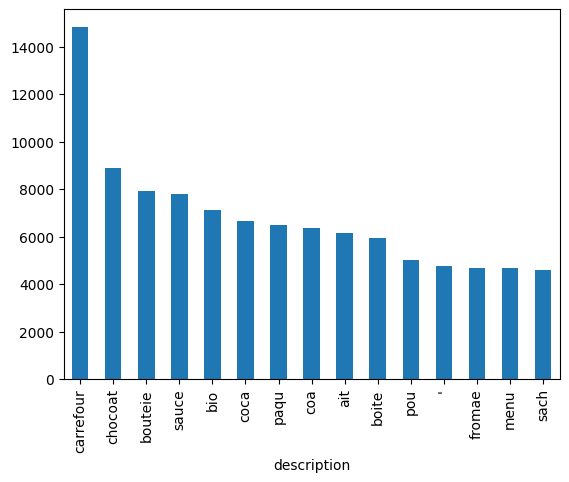

In [ ]:
products.explode().value_counts().head(15).plot.bar()

## 5.2. Saturación en semana.

In [ ]:
copy_set = df.copy()
copy_set['weekday_courier_started'] = copy_set['courier_started_order_local'].dt.day_name()
copy_set['hour_courier_started'] = copy_set['courier_started_order_local'].dt.hour

In [ ]:
df_grouped = (
    copy_set.groupby(by='weekday_courier_started')['saturation']
      .sum()
      .to_frame('saturacion')
      .sort_values(by='saturacion', ascending=False)
)

fig = go.Figure(
    data=[
        go.Bar(
            x=df_grouped.index.astype(str),
            y=df_grouped['saturacion'],
            marker=dict(
                color=df_grouped['saturacion'],
                colorscale='Viridis',
                colorbar=dict(title='Saturation')
            )
        )
    ]
)

fig.update_layout(
    title='Saturación por Día de la semana (Aceptación del pedido',
    xaxis_title='Weekday',
    yaxis_title='Saturation'
)

fig.show()

In [ ]:
df_grouped = (
    copy_set.groupby(by='hour_courier_started')['saturation']
      .sum()
      .to_frame('saturacion')
      .sort_values(by='saturacion', ascending=False)
)

fig = go.Figure(
    data=[
        go.Bar(
            x=df_grouped.index.astype(str),
            y=df_grouped['saturacion'],
            marker=dict(
                color=df_grouped['saturacion'],
                colorscale='Viridis',
                colorbar=dict(title='Saturation')
            )
        )
    ]
)

fig.update_layout(
    title='Saturación por Hora de aceptación del pedido.',
    xaxis_title='Hora',
    yaxis_title='Saturación',
)

fig.show()

## 5.3. Tiempos, repartos y post-entrega

In [ ]:
# Eliminamos variables post-entrega (data leakage)
df = df.drop(columns=['rating', 'bad_rating_reason'])

# Eliminamos 4 filas sin registro del repartidor
df = df.dropna(subset=['courier_started_order_local']).copy()

# Para los envíos de la vertical COURIER (de persona a persona), la tienda está vacía.
# Rellenamos estos valores para no perder la información y poder usarlos en el modelo.
df['store_address_id'] = df['store_address_id'].fillna(-1)
df['store_name'] = df['store_name'].fillna('C2C_Delivery')

# Imputamos las descripciones vacías (32 filas) para que el código de extracción
# de ítems que usaremos más adelante no arroje errores.
df['description'] = df['description'].fillna('Sin descripcion')

# Convertir timestamps
time_cols = [
    'activation_time_local', 'courier_started_order_local',
    'pickup_time_local', 'delivery_time_local'
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

df = df.sort_values(by=['courier_id', 'courier_started_order_local']).reset_index(drop=True)
print(f'Dataset limpio: {df.shape[0]:,} filas')

Dataset limpio: 63,642 filas


# 6. Feature Engineering

## 6.1 Cambio 1 — Variables de Batching

In [ ]:
# ── BATCHING ──────────────────────────────────────────────────────────────────
# Un pedido está en batch si se solapa temporalmente con otro del mismo repartidor.
# Lógica: ¿el pedido actual empezó antes de que terminara el anterior?
overlaps_prev = df['courier_started_order_local'] < df.groupby('courier_id')['delivery_time_local'].shift(1)
# ¿El siguiente pedido del repartidor empezó antes de que terminara este?
overlaps_next = df.groupby('courier_id')['courier_started_order_local'].shift(-1) < df['delivery_time_local']

df['is_batched']    = (overlaps_prev | overlaps_next).astype(int)
df['batch_group']   = (~df['is_batched'].astype(bool)).cumsum()
df['batch_position']= df.groupby(['courier_id', 'batch_group']).cumcount() + 1

print('Pedidos en batch:', df['is_batched'].sum(), f'({df["is_batched"].mean()*100:.1f}%)')
print('Distribución de posición en batch:')
print(df['batch_position'].value_counts().head(5))

Pedidos en batch: 19991 (31.4%)
Distribución de posición en batch:
batch_position
1    43670
2     6830
3     6812
4     2597
5     1714
Name: count, dtype: int64


## 6.2 Cambio 2 — Demanda en tiempo real

In [ ]:
# ── VENTANA ESTÁTICA 5 MIN ────────────────────────────────────────────────────
# Redondeamos la activación a bloques de 5 min y contamos el volumen
df['time_window_5m'] = df['activation_time_local'].dt.floor('5min')
window_counts = df.groupby('time_window_5m').size().reset_index(name='orders_in_5m_window')
df = df.merge(window_counts, on='time_window_5m', how='left')
# Despejamos la fórmula de saturación para estimar la cantidad de repartidores conectados
df['estimated_couriers_5m'] = (
    df['orders_in_5m_window'] / (df['saturation'].replace(0, 1) / 100.0)
).round().astype(int)
df = df.drop(columns=['time_window_5m'])

# ── COLA DE EVENTOS LIVE ─────────────────────────────────────────────────────
# Registramos las entradas (+1) y salidas (-1) de pedidos del sistema
df_act = pd.DataFrame({'timestamp': df['activation_time_local'].astype('datetime64[ns]'),  'order_diff':  1})
df_del  = pd.DataFrame({'timestamp': df['delivery_time_local'].astype('datetime64[ns]'),    'order_diff': -1})
# Ordenamos todos los eventos y calculamos el volumen acumulado en tiempo real
df_events = pd.concat([df_act, df_del]).sort_values('timestamp')
df_events['live_orders'] = df_events['order_diff'].cumsum()
df_events = df_events.drop_duplicates(subset=['timestamp'], keep='last')

# Cruzamos este dato en vivo usando merge_asof para buscar la carga exacta
# en el momento en que el usuario hizo clic en "comprar"
df = df.sort_values('activation_time_local')
df = pd.merge_asof(
    df,
    df_events[['timestamp', 'live_orders']],
    left_on='activation_time_local',
    right_on='timestamp',
    direction='backward'
).drop(columns=['timestamp'])

# Al igual que antes, estimamos la flota "Live" usando la demanda y la saturación
df['live_couriers'] = (
    df['live_orders'] / (df['saturation'].replace(0, 1) / 100.0)
).round().astype(int)

print('Variables de demanda creadas ✓')
print(f'  orders_in_5m_window — media: {df["orders_in_5m_window"].mean():.1f}')
print(f'  live_orders         — media: {df["live_orders"].mean():.1f}')
print(f'  live_couriers       — media: {df["live_couriers"].mean():.1f}')

Variables de demanda creadas ✓
  orders_in_5m_window — media: 5.5
  live_orders         — media: 34.9
  live_couriers       — media: 56.9


## 6.3. Cambio 3 — Variables de calendario, distancia e ítems



In [ ]:
# TARGET: El tiempo total a predecir (en minutos)
df['target_total_delivery_time_min'] = (
    (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60
)

# Calendario
# Variables de calendario para modelar el tráfico de la ciudad
df['hour_of_day']  = df['activation_time_local'].dt.hour
df['day_of_week']  = df['activation_time_local'].dt.dayofweek
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)

# Haversine: Distancia en línea recta (Fórmula Haversine en km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['delivery_distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['delivery_latitude'], df['delivery_longitude']
)

# Ítems: Busca patrones como "2x Hamburguesa" en la descripción
# El modelo sabrá que un volumen alto implica más tiempo en cocina
def parse_item_count(text):
    if text == 'Sin descripcion': return 1
    matches = re.findall(r'(\d+)\s*[xX]', str(text))
    return sum(int(m) for m in matches) if matches else 1

df['total_items'] = df['description'].apply(parse_item_count)

# Encoding transporte y vertical:
# Transformamos BICYCLE a 0 y MOTORBIKE a 1 (Label Encoding)
# Creamos columnas binarias para cada categoría de vertical (One-Hot Encoding)
df['transport_type_num'] = df['tranport_type'].map({'BICYCLE': 0, 'MOTORBIKE': 1}).fillna(-1).astype(int)
df = pd.get_dummies(df, columns=['vertical'], prefix='is', dtype=int)
df.columns = [col.replace(' ', '_').replace('-', '').replace('__', '_').lower() for col in df.columns]

# Perfil histórico de tienda
df['assignment_time_min']       = (df['courier_started_order_local'] - df['activation_time_local']).dt.total_seconds() / 60
df['courier_to_store_time_min'] = (df['pickup_time_local'] - df['courier_started_order_local']).dt.total_seconds() / 60

# Perfilado Histórico del Restaurante: Media del tiempo de espera del repartidor
store_wait = df.groupby('store_address_id')['courier_to_store_time_min'].mean().reset_index()
store_wait.rename(columns={'courier_to_store_time_min': 'store_historical_wait_time_min'}, inplace=True)
# Cruzamos este historial y a los restaurantes nuevos les imputamos la mediana global
df = df.merge(store_wait, on='store_address_id', how='left')
df['store_historical_wait_time_min'] = df['store_historical_wait_time_min'].fillna(
    df['store_historical_wait_time_min'].median()
)

print('Feature engineering base completado ✓')

Feature engineering base completado ✓


## 6.4. Cambio 4 — Franja horaria (time_slot)

In [ ]:
# ── FRANJA HORARIA ────────────────────────────────────────────────────────────
# Agrupamos las 24 horas en franjas operacionales significativas
# Esto permite capturar patrones no lineales que hour_of_day numérico no puede.

#  0  → Madrugada  (00–06): volumen muy bajo, tráfico mínimo
#  1  → Mañana     (07–10): inicio de actividad, tráfico moderado
#  2  → Almuerzo   (11–14): pico de demanda alimentaria, máxima saturación
#  3  → Tarde      (15–18): descenso, tráfico laboral de salida
#  4  → Cena       (19–22): segundo pico, alta saturación
#  5  → Noche      (23):    cierre, volumen bajo

def assign_time_slot(hour):
    if 0  <= hour < 7:  return 0   # madrugada
    if 7  <= hour < 11: return 1   # mañana
    if 11 <= hour < 15: return 2   # almuerzo (pico 1)
    if 15 <= hour < 19: return 3   # tarde
    if 19 <= hour < 23: return 4   # cena (pico 2)
    return 5                        # noche

SLOT_LABELS = {
    0: 'Madrugada (00-06)',
    1: 'Mañana (07-10)',
    2: 'Almuerzo (11-14)',
    3: 'Tarde (15-18)',
    4: 'Cena (19-22)',
    5: 'Noche (23)'
}

df['time_slot'] = df['hour_of_day'].apply(assign_time_slot)

# Visualización de la distribución por franja
slot_stats = df.groupby('time_slot').agg(
    ordenes=('order_id', 'count'),
    eta_media=('target_total_delivery_time_min', 'mean'),
    saturacion_media=('saturation', 'mean')
).reset_index()
slot_stats['franja'] = slot_stats['time_slot'].map(SLOT_LABELS)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Volumen de órdenes por franja', 'ETA medio por franja (min)']
)
colors = ['#4da8da', '#45f5a5', '#e94560', '#f5c542', '#ff6b6b', '#bb86fc']
fig.add_trace(go.Bar(x=slot_stats['franja'], y=slot_stats['ordenes'],
                     marker_color=colors, name='Órdenes'), row=1, col=1)
fig.add_trace(go.Bar(x=slot_stats['franja'], y=slot_stats['eta_media'].round(1),
                     marker_color=colors, name='ETA medio'), row=1, col=2)
fig.update_layout(template='plotly_dark', paper_bgcolor='#0f0f1a', plot_bgcolor='#1a1a2e',
                  title='Análisis por Franja Horaria', height=400, showlegend=False)
fig.update_xaxes(tickangle=-20)
fig.show()
print(slot_stats[['franja', 'ordenes', 'eta_media', 'saturacion_media']].to_string(index=False))

          franja  ordenes  eta_media  saturacion_media
  Mañana (07-10)     6961  41.088084         83.191065
Almuerzo (11-14)    20104  37.838080         77.301930
   Tarde (15-18)    16717  38.808188         78.986959
    Cena (19-22)    19063  36.803144         75.275403
      Noche (23)      797  36.952070         76.508156


## 6.5 Análisis de matriz de correlación con nuevas variables

In [ ]:
corr_cols = [
    'target_total_delivery_time_min',
   'live_orders',
    'live_couriers',
    'saturation',


    'hour_of_day', 'day_of_week', 'is_weekend',
    'delivery_distance_km', 'total_items',
    'transport_type_num', 'store_historical_wait_time_min',
    'orders_in_5m_window',

    'is_batched', 'batch_position',
    'time_slot',
]

corr = df[corr_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix'
)
fig.update_layout(width=1000, height=1000)

fig.show()

In [ ]:
correlations_with_target = corr['target_total_delivery_time_min'].drop('target_total_delivery_time_min')

top_5_correlated = correlations_with_target.abs().sort_values(ascending=False).head(5)

print("Top 5 de variables más correlacionadas con 'target_total_delivery_time_min':")
print(top_5_correlated)

Top 5 de variables más correlacionadas con 'target_total_delivery_time_min':
saturation                        0.778421
live_couriers                     0.443343
delivery_distance_km              0.352054
store_historical_wait_time_min    0.126873
hour_of_day                       0.062483
Name: target_total_delivery_time_min, dtype: float64


Basados en estos resultados vemos que tenemos una mayor correlación entre las features que se han calculado. Usaremos las mismas para la creación del pipeline, datos de entrenamiento y modelos.

# 7. Preprocesamiento de la data - Entrenamiento

## 7.1. Pipeline de preprocesamiento

In [ ]:
# ── FEATURES FINALES ───────────────────────────────────────────────────────
features_finales = [
    'hour_of_day', 'day_of_week', 'is_weekend',
    'delivery_distance_km', 'total_items',
    'transport_type_num', 'store_historical_wait_time_min',
    'orders_in_5m_window', 'live_orders', 'live_couriers',
    'is_batched', 'batch_position',
    'time_slot'
]

features_finales_v2 = [
    'hour_of_day', 'day_of_week', 'is_weekend',
    'delivery_distance_km', 'total_items',
    'transport_type_num', 'store_historical_wait_time_min',
    'orders_in_5m_window', 'saturation'
    'is_batched', 'batch_position',
    'time_slot'
]

print(f'Número de features:  {len(features_finales)}')

Número de features:  13


In [ ]:
# 1. PASO: extracción de variables
class GlovoFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
         # Convertir a datetime y extraer tiempos
        for col in ['activation_time_local']:
            if col in X.columns:
                X[col] = pd.to_datetime(X[col])
        X['hour_of_day'] = X['activation_time_local'].dt.hour
        X['day_of_week'] = X['activation_time_local'].dt.dayofweek
        X['is_weekend']  = X['day_of_week'].isin([5, 6]).astype(int)
        X['time_slot']   = X['hour_of_day'].apply(assign_time_slot)
        return X

# 2. PASO: limpieza de outliers
class GlovoOutlierCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, max_dist=25, max_time=180, max_items=40):
        self.max_dist = max_dist; self.max_time = max_time; self.max_items = max_items
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X = X[(X['delivery_distance_km'] > 0) & (X['delivery_distance_km'] <= self.max_dist)]
        X = X[X['total_items'] <= self.max_items]
        return X

pipeline_v2 = Pipeline(steps=[
    ('extractor', GlovoFeatureExtractor()),
    ('cleaner',   GlovoOutlierCleaner()),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',    RobustScaler())
])

def get_processed_data(df, target_col, pipeline, features):
    # 1. Ejecutamos los pasos de Extracción y Limpieza primero
    # para identificar qué índices (filas) se mantienen.
    X_temp    = pipeline.named_steps['extractor'].transform(df)
    X_cleaned = pipeline.named_steps['cleaner'].transform(X_temp)

    # 2. Filtramos el vector objetivo (y) usando los índices que sobrevivieron
    valid_idx = X_cleaned.index
    y_final   = df.loc[valid_idx, target_col]

    # 3. Aplicamos los pasos restantes de la pipeline (Imputer y Scaler)
    # sobre las columnas que realmente vamos a usar para el modelo.
    X_scaled  = pipeline.named_steps['imputer'].fit_transform(X_cleaned[features])
    X_scaled  = pipeline.named_steps['scaler'].fit_transform(X_scaled)
    return pd.DataFrame(X_scaled, columns=features, index=valid_idx), y_final

# Convertimos a DataFrame para mantener la legibilidad (opcional)
X_final, y_final = get_processed_data(df, 'target_total_delivery_time_min', pipeline_v2, features_finales)
print(f'Dataset procesado: {X_final.shape[0]:,} filas × {X_final.shape[1]} features')

Dataset procesado: 63,572 filas × 13 features


## 7.2. División Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Guardamos también el time_slot del test para la evaluación estratificada (Mejora 6)
# Recuperamos desde el df original usando los índices supervivientes
test_slots = df.loc[X_test.index, 'time_slot'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 50,857 | Test: 12,715


# 8. Modelado

## 8.1. Entrenamiento de modelos

Como base de evaluación consideramos usar está métricas de evaluación:
*   MAE — Mide el promedio de los errores de predicción en las mismas unidades que el problema (minutos), lo que nos permite entender de forma directa y sin distorsiones cuánto se equivoca el modelo en un caso típico
*   RMSE — Mide también el error promedio, pero penalizando más los errores grandes al elevarlos al cuadrado, lo que nos permite detectar si existen casos puntuales donde el modelo falla de forma severa más allá del comportamiento habitual.
*   R² — Mide qué proporción de la variabilidad total del tiempo de entrega es explicada por el modelo, lo que nos permite evaluar su capacidad predictiva real en relación a simplemente usar la media como estimación constante.

Con base en este detalle se proponen los siguientes 4 modelos:


### 8.1.1. Modelo 1 — Regresión Lineal (Baseline)

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f'Linear Regression — MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.3f}')

Linear Regression — MAE: 9.21 | RMSE: 12.28 | R²: 0.360


###Análisis de las métricas:

**MAE (Error Absoluto Medio):** 10.35 minutos

En promedio, el modelo se equivoca en 10.35 minutos al predecir el tiempo total de entrega. Esto significa que, en promedio, la diferencia entre el tiempo predicho y el tiempo real de entrega es de unos 10 minutos y 21 segundos.

**RMSE (Raíz del Error Cuadrático Medio):** 13.93 minutos

Este valor penaliza más los errores grandes. Un RMSE de 13.93 minutos indica que los errores más significativos son mayores que los del MAE. Es una métrica útil para ver si hay errores atípicos muy grandes.

**R2 Score (Coeficiente de Determinación):** 0.18

El R2 Score mide la proporción de la varianza en la variable dependiente (tiempo de entrega) que es predecible a partir de las variables independientes. Un valor de 0.18 significa que el modelo actual explica aproximadamente el 18% de la variabilidad en los tiempos de entrega. Este valor es relativamente bajo, lo que sugiere que hay mucha variabilidad en los tiempos de entrega que el modelo aún no puede explicar. Podría indicar que el modelo actual no es muy predictivo o que las características que estamos usando no son suficientes para capturar la complejidad de los datos.
En resumen, el modelo baseline es un punto de partida, pero las métricas sugieren que hay un amplio margen de mejora para predecir con mayor precisión el tiempo de entrega.


### 8.1.2. Modelo 2 — XGBoost

In [ ]:
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
print(f'XGBoost — MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | R²: {r2_xgb:.3f}')

XGBoost — MAE: 6.91 | RMSE: 8.72 | R²: 0.678


### Análisis de las métricas (XGBoost):

**MAE (Error Absoluto Medio):** 6.91 minutos

En promedio, el modelo XGBoost se equivoca en 6.91 minutos al predecir el tiempo total de entrega. Esto representa una mejora significativa en comparación con el MAE de 9.21 minutos del modelo de Regresión Lineal, indicando predicciones considerablemente más precisas.

**RMSE (Raíz del Error Cuadrático Medio):** 8.72 minutos

El RMSE de 8.72 minutos para XGBoost es sustancialmente menor que el 12.28 minutos de la Regresión Lineal. Esto sugiere que no solo los errores promedio son menores, sino que también los errores grandes y atípicos se han reducido, haciendo que el modelo sea más robusto y fiable.

**R2 Score (Coeficiente de Determinación):** 0.678

Un R2 Score de 0.678 significa que el modelo XGBoost explica aproximadamente el 67.8% de la variabilidad en los tiempos de entrega. Esto es una mejora considerable respecto al 0.360 de la Regresión Lineal, indicando que XGBoost captura una proporción mucho mayor de la complejidad de los datos y tiene un poder predictivo mucho más alto.

En resumen, el modelo XGBoost demuestra un rendimiento muy superior al de la Regresión Lineal, con errores de predicción significativamente menores y una capacidad mucho mayor para explicar la variabilidad en los tiempos de entrega.

### 8.1.3. Modelo 3 — Random Forest

In [ ]:
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f'Random Forest — MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.3f}')

Random Forest — MAE: 6.98 | RMSE: 8.82 | R²: 0.670


### Análisis de las métricas (Random Forest):

**MAE (Error Absoluto Medio):** 6.98 minutos

El modelo Random Forest muestra un Error Absoluto Medio de 6.98 minutos. Esto indica que, en promedio, las predicciones del tiempo de entrega se desvían en aproximadamente 7 minutos del valor real. Es un rendimiento muy similar al de XGBoost y significativamente mejor que el de la Regresión Lineal.

**RMSE (Raíz del Error Cuadrático Medio):** 8.82 minutos

El RMSE para Random Forest es de 8.82 minutos. Al igual que el MAE, este valor es muy cercano al de XGBoost, sugiriendo que el modelo maneja los errores grandes de manera comparable y supera ampliamente a la Regresión Lineal.

**R2 Score (Coeficiente de Determinación):** 0.670

Con un R² de 0.670, el modelo Random Forest explica aproximadamente el 67% de la variabilidad en los tiempos de entrega. Este valor es también muy similar al de XGBoost (0.678) y representa una gran mejora sobre el modelo base de Regresión Lineal, lo que lo convierte en un modelo predictivo robusto.

### 8.1.4. Modelo 4 — LightGBM

In [ ]:
# ── LIGHTGBM ──────────────────────────────────────────────────────────────────
# LightGBM usa un algoritmo de histogramas (Histogram-based Gradient Boosting)
# que lo hace hasta 20× más rápido que XGBoost con datasets de más de 50k filas.
# Además, es nativamente compatible con variables categóricas ordinales.

model_lgb = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,          # L1 regularización
    reg_lambda=1.0,         # L2 regularización
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb   = r2_score(y_test, y_pred_lgb)
print(f'LightGBM — MAE: {mae_lgb:.2f} | RMSE: {rmse_lgb:.2f} | R²: {r2_lgb:.3f}')

LightGBM — MAE: 6.91 | RMSE: 8.72 | R²: 0.678


### Análisis de las métricas (LightGBM):

**MAE (Error Absoluto Medio):** 6.91 minutos

El modelo LightGBM presenta un MAE de 6.91 minutos, lo que significa que, en promedio, se desvía de los tiempos de entrega reales por aproximadamente 6.91 minutos. Este es el mismo rendimiento en MAE que el modelo XGBoost, y ambos son considerablemente mejores que la Regresión Lineal.

**RMSE (Raíz del Error Cuadrático Medio):** 8.72 minutos

El RMSE de 8.72 minutos para LightGBM es idéntico al de XGBoost. Esto indica que la magnitud de los errores de predicción, incluyendo los más grandes, es muy similar entre ambos modelos y que ambos superan con creces a la Regresión Lineal.

**R2 Score (Coeficiente de Determinación):** 0.678

El R² de 0.678 para LightGBM es el mismo que el de XGBoost. Esto significa que ambos modelos explican aproximadamente el 67.8% de la variabilidad en los tiempos de entrega, lo que los posiciona como los modelos con mayor poder explicativo y predictivo de los cuatro evaluados.

## 8.2. Cross-Validation — Comparativa de los 4 modelos

In [ ]:
modelos = {
    'Linear Regression': model_lr,
    'Random Forest':     model_rf,
    'XGBoost':           model_xgb,
    'LightGBM':          model_lgb,
}

resultados_cv = {}
print('\n── Cross-Validation (5-Fold) ───')
for name, model in modelos.items():
    # Calculate MAE scores
    scores_mae = cross_val_score(
        model, X_final, y_final,
        cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mae_mean = -scores_mae.mean()
    mae_std  = scores_mae.std()

    # Calculate RMSE scores
    scores_rmse = cross_val_score(
        model, X_final, y_final,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_mean = -scores_rmse.mean()
    rmse_std  = scores_rmse.std()

    # Calculate R2 scores
    scores_r2 = cross_val_score(
        model, X_final, y_final,
        cv=kf, scoring='r2', n_jobs=-1
    )
    r2_mean = scores_r2.mean()
    r2_std  = scores_r2.std()

    resultados_cv[name] = {
        'mae': mae_mean, 'mae_std': mae_std,
        'rmse': rmse_mean, 'rmse_std': rmse_std,
        'r2': r2_mean, 'r2_std': r2_std
    }
    print(f'  {name:<22}  MAE = {mae_mean:.3f} (±{mae_std:.3f})')
    print(f'  {name:<22}  RMSE = {rmse_mean:.3f} (±{rmse_std:.3f})')
    print(f'  {name:<22}  R² = {r2_mean:.3f} (±{r2_std:.3f})\n')

# Gráfico comparativo MAE
df_cv_mae = pd.DataFrame([
    {'Modelo': k, 'MAE': v['mae'], 'Std': v['mae_std']}
    for k, v in resultados_cv.items()
]).sort_values('MAE')

fig = go.Figure()
palette = ['#4da8da', '#45f5a5', '#f5c542', '#e94560']
for i, (_, row) in enumerate(df_cv_mae.iterrows()):
    fig.add_trace(go.Bar(
        name=row['Modelo'], x=[row['Modelo']], y=[row['MAE']],
        error_y=dict(type='data', array=[row['Std']], visible=True),
        marker_color=palette[i],
        text=f"{row['MAE']:.3f}", textposition='outside'
    ))
fig.update_layout(
    title='Comparativa MAE — Cross-Validation 5-Fold (menor es mejor)',
    yaxis_title='MAE (minutos)', template='plotly_dark',
    paper_bgcolor='#0f0f1a', plot_bgcolor='#1a1a2e',
    showlegend=False, height=450
)
fig.show()



── Cross-Validation (5-Fold) ───
  Linear Regression       MAE = 9.380 (±0.096)
  Linear Regression       RMSE = 12.562 (±0.176)
  Linear Regression       R² = 0.354 (±0.004)

  Random Forest           MAE = 7.056 (±0.044)
  Random Forest           RMSE = 8.890 (±0.060)
  Random Forest           R² = 0.677 (±0.007)

  XGBoost                 MAE = 6.975 (±0.045)
  XGBoost                 RMSE = 8.785 (±0.057)
  XGBoost                 R² = 0.684 (±0.007)

  LightGBM                MAE = 6.978 (±0.044)
  LightGBM                RMSE = 8.783 (±0.052)
  LightGBM                R² = 0.684 (±0.006)



### Evaluación del Cross-Validation (5-Fold, MAE):

La evaluación mediante Cross-Validation (5-Fold) utilizando el Error Absoluto Medio (MAE) como métrica principal, confirma el buen rendimiento de los modelos de ensamblaje (XGBoost, LightGBM, Random Forest) en comparación con la Regresión Lineal.

- **XGBoost:** MAE = 6.975 (±0.045) min
- **LightGBM:** MAE = 6.978 (±0.044) min
- **Random Forest:** MAE = 7.056 (±0.044) min
- **Linear Regression:** MAE = 9.380 (±0.096) min

Estos resultados muestran que XGBoost y LightGBM ofrecen la mejor precisión y robustez, con valores de MAE muy similares y una baja desviación estándar en las diferentes divisiones de la validación cruzada. Random Forest también presenta un rendimiento sólido, superando ampliamente a la Regresión Lineal.

## 8.3. Importancia de features — Modelo ganador

Generamos una evaluación entre amnbos modelos con mejores resultados (MAE) y evaluamos cuales son las caraterísticas que mejor representan el comportamiento de este modelo, aquí evaluamos la posibilidad de poder crear un modelo basado en caractéristicas específicas de cada uno.

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Definición de colores (Inspirados en tu referencia)
color_teal = '#108e71'
color_yellow = '#f1c232'

# 2. Preparación de datos
importances_lgb = model_lgb.feature_importances_
importances_xgb = model_xgb.feature_importances_

df_imp = pd.DataFrame({
    'Feature': features_finales,
    'LightGBM': importances_lgb / importances_lgb.sum(),
    'XGBoost':  importances_xgb / importances_xgb.sum()
})

# Filtrar el Top 5 basado en LightGBM
df_top5 = df_imp.nlargest(5, 'LightGBM').sort_values('LightGBM', ascending=True)

# 3. Creación del gráfico
fig = go.Figure()

# Trace LightGBM
fig.add_trace(go.Bar(
    y=df_top5['Feature'],
    x=df_top5['LightGBM'],
    orientation='h',
    name='LightGBM',
    marker_color=color_teal
))

# Trace XGBoost
fig.add_trace(go.Bar(
    y=df_top5['Feature'],
    x=df_top5['XGBoost'],
    orientation='h',
    name='XGBoost',
    marker_color=color_yellow
))

# 4. Configuración del Layout
fig.update_layout(
    title='Top 5 Importancia de Features',
    xaxis_title='Importancia relativa (normalizada)',
    # CAMBIO CLAVE: 'group' para que no se traslapen los colores
    barmode='group',
    template='plotly_white',
    height=450,
    width=1000,
    font=dict(family="Arial", size=14, color="black"),
    margin=dict(l=200),
    legend=dict(x=0.8, y=0.15),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Ajuste de ejes y rejilla
fig.update_xaxes(showgrid=True, gridcolor='lightgray', range=[0, 0.55])
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Color Teal
color_teal = '#108e71'

# 2. Datos
importances_lgb = model_lgb.feature_importances_
df_imp = pd.DataFrame({
    'Feature': features_finales,
    'LightGBM': importances_lgb / importances_lgb.sum()
})

# Filtrar el Top 5
df_top5 = df_imp.nlargest(5, 'LightGBM').sort_values('LightGBM', ascending=True)

# 3. Gráfico
fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_top5['Feature'],
    x=df_top5['LightGBM'],
    orientation='h',
    marker_color=color_teal,
    text=(df_top5['LightGBM'] * 100).round(1).astype(str) + '%',
    textposition='auto'
))

# 4. Layout Ajustado (Mejor estética para 5 barras)
fig.update_layout(
    title='Top 5 Importancia de Features — LightGBM',
    xaxis_title='Importancia relativa (normalizada)',
    template='plotly_white',
    height=350,      # Altura reducida para que las barras no se vean tan "gordas"
    width=850,       # Ancho ajustado para que no sobre tanto espacio
    font=dict(family="Arial", size=13),
    margin=dict(l=220, r=40, t=80, b=50),
    plot_bgcolor='white',
    paper_bgcolor='white',
    bargap=0.4       # Mayor separación entre las barras
)

# Ajuste automático del eje X (quitamos el range=[0, 0.55])
fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:


# Calculamos importancia normalizada solo para LightGBM
importances_lgb = model_lgb.feature_importances_

df_imp = pd.DataFrame({
    'Feature': features_finales,
    'LightGBM': importances_lgb / importances_lgb.sum()
}).sort_values('LightGBM', ascending=True)

# Generamos el gráfico
fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_imp['Feature'],
    x=df_imp['LightGBM'],
    orientation='h',
    name='LightGBM',
    marker_color='#4da8da',
    opacity=0.85
))

fig.update_layout(
    title='Importancia de Features (LightGBM)',
    xaxis_title='Importancia relativa (normalizada)',
    template='plotly_dark',
    paper_bgcolor='#0f0f1a',
    plot_bgcolor='#1a1a2e',
    height=550
)

fig.show()

La gráfica anterior presenta la importancia relativa de las diferentes características (features) utilizadas en los modelos LightGBM y XGBoost para predecir el tiempo de entrega.

**Observaciones clave:**

*   **Consistencia entre modelos:** Ambos modelos (LightGBM y XGBoost) muestran una alta consistencia en la valoración de la importancia de las features, aunque con ligeras variaciones en la magnitud.
*   **Características más influyentes:** Las características relacionadas con la **demanda en tiempo real** (live_couriers, live_orders, orders_in_5m_window), la **distancia de entrega** (delivery_distance_km), y el **tiempo histórico de espera en la tienda** (store_historical_wait_time_min) son consistentemente las más importantes. Esto sugiere que estos factores son cruciales para determinar el tiempo total de entrega.
*   **Otras características relevantes:** La hour_of_day (hora del día) también juega un papel significativo, lo cual es lógico ya que la demanda y el tráfico varían considerablemente a lo largo del día. batch_position y time_slot también aportan valor predictivo.
*   **Características menos influyentes:** is_weekend (si es fin de semana) y transport_type_num (tipo de transporte) tienen una importancia menor en comparación con las otras, aunque siguen siendo consideradas por los modelos.

## 8.4. Modelización agregada

### 8.4.1. Predicción por Intervalo de Confianza (Predicción Conforme)

En lugar de darte una única estimación de ETA (por ejemplo, '25 minutos'), este método nos permite ofrecer un rango de tiempo con una confianza garantizada. Usamos **"Split Conformal Prediction"**

Procedimiento:

1.  **Dividimos los datos:** Tomamos nuestros datos de entrenamiento y los separamos en dos grupos: uno grande (80%) para entrenar nuestro modelo y uno más pequeño (20%) para ver dónde se equivoca.
2.  **Entrenamos el modelo:** Usamos el modelo LightGBM con la parte grande de los datos para que aprenda a predecir el ETA.
3.  **Medimos los errores:** Con la parte pequeña de los datos ("calibración"), medimos cuánto se desvía el modelo de la realidad.
4.  **Creamos el rango:** Con esas puntuaciones de error, calculamos un "margen de seguridad". Cuando el modelo predice un nuevo ETA, le sumamos y restamos este margen para obtener nuestro rango de tiempo.



In [ ]:
# ── SPLIT CONFORMAL PREDICTION  ─
# Dividir train en proper_train + calibracion
X_proper, X_calib, y_proper, y_calib = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=99
)
print(f'Proper train: {len(X_proper):,} | Calibracion: {len(X_calib):,}')

# Entrenar LightGBM en proper_train
lgb_conformal = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=7,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_conformal.fit(X_proper, y_proper)

# Nonconformity scores en calibracion
scores_calib = np.abs(y_calib.values - lgb_conformal.predict(X_calib))
print(f'Score medio en calibracion: {scores_calib.mean():.2f} min')

# Funcion de cuantil conformal con correccion (n+1)/n
def conformal_quantile(scores, confidence_level):
    n = len(scores)
    q_level = np.ceil((n + 1) * confidence_level) / n
    q_level = min(q_level, 1.0)
    return float(np.quantile(scores, q_level))

q_60 = conformal_quantile(scores_calib, 0.60)
q_80 = conformal_quantile(scores_calib, 0.80)
q_95 = conformal_quantile(scores_calib, 0.95)
print(f'Radio del intervalo @60%: +/-{q_60:.2f} min')
print(f'Radio del intervalo @80%: +/-{q_80:.2f} min')
print(f'Radio del intervalo @95%: +/-{q_95:.2f} min')

# Predicciones e intervalos sobre TEST
y_pred_mapie = lgb_conformal.predict(X_test)   # punto central

lower_60 = y_pred_mapie - q_60
upper_60 = y_pred_mapie + q_60
lower_80 = y_pred_mapie - q_80
upper_80 = y_pred_mapie + q_80
lower_95 = y_pred_mapie - q_95
upper_95 = y_pred_mapie + q_95

# Metricas de cobertura
y_test_arr  = y_test.values
coverage_60 = ((y_test_arr >= lower_60) & (y_test_arr <= upper_60)).mean()
coverage_80 = ((y_test_arr >= lower_80) & (y_test_arr <= upper_80)).mean()
coverage_95 = ((y_test_arr >= lower_95) & (y_test_arr <= upper_95)).mean()
width_60    = q_60 * 2
width_80    = q_80 * 2
width_95    = q_95 * 2
mae_mapie   = mean_absolute_error(y_test_arr, y_pred_mapie)

print(f'\n-- Metricas Conformal Prediction --------------------------------')
print(f'  MAE (punto central):        {mae_mapie:.2f} min')
print(f'  Cobertura real  @60%:       {coverage_60*100:.1f}%  (objetivo: >= 60%)')
print(f'  Cobertura real  @80%:       {coverage_80*100:.1f}%  (objetivo: >= 80%)')
print(f'  Cobertura real  @95%:       {coverage_95*100:.1f}%  (objetivo: >= 95%)')
print(f'  Ancho intervalo @60%:       {width_60:.1f} min')
print(f'  Ancho intervalo @80%:       {width_80:.1f} min')
print(f'  Ancho intervalo @95%:       {width_95:.1f} min')

Proper train: 40,685 | Calibracion: 10,172
Score medio en calibracion: 6.96 min
Radio del intervalo @60%: +/-7.34 min
Radio del intervalo @80%: +/-10.87 min
Radio del intervalo @95%: +/-17.03 min

-- Metricas Conformal Prediction --------------------------------
  MAE (punto central):        6.92 min
  Cobertura real  @60%:       60.5%  (objetivo: >= 60%)
  Cobertura real  @80%:       80.1%  (objetivo: >= 80%)
  Cobertura real  @95%:       94.9%  (objetivo: >= 95%)
  Ancho intervalo @60%:       14.7 min
  Ancho intervalo @80%:       21.7 min
  Ancho intervalo @95%:       34.1 min


In [ ]:
# ── VISUALIZACIÓN DEL INTERVALO DE CONFIANZA ──────────────────────────────────
# Mostramos las primeras 150 predicciones del test ordenadas por valor real
n_show = 150
sort_idx = np.argsort(y_test_arr[:n_show])

y_real_sorted   = y_test_arr[:n_show][sort_idx]
y_pred_sorted   = y_pred_mapie[:n_show][sort_idx]
lower_60_sorted = lower_60[:n_show][sort_idx]
upper_60_sorted = upper_60[:n_show][sort_idx]
lower_80_sorted = lower_80[:n_show][sort_idx]
upper_80_sorted = upper_80[:n_show][sort_idx]
lower_95_sorted = lower_95[:n_show][sort_idx]
upper_95_sorted = upper_95[:n_show][sort_idx]
x_idx           = np.arange(n_show)

fig = go.Figure()

# Banda 95%
fig.add_trace(go.Scatter(
    x=np.concatenate([x_idx, x_idx[::-1]]),
    y=np.concatenate([upper_95_sorted, lower_95_sorted[::-1]]),
    fill='toself', fillcolor='rgba(77,168,218,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='IC 95%'
))
# Banda 80%
fig.add_trace(go.Scatter(
    x=np.concatenate([x_idx, x_idx[::-1]]),
    y=np.concatenate([upper_80_sorted, lower_80_sorted[::-1]]),
    fill='toself', fillcolor='rgba(77,168,218,0.35)',
    line=dict(color='rgba(0,0,0,0)'), name='IC 80%'
))
# Banda 60%
fig.add_trace(go.Scatter(
    x=np.concatenate([x_idx, x_idx[::-1]]),
    y=np.concatenate([upper_60_sorted, lower_60_sorted[::-1]]),
    fill='toself', fillcolor='rgba(77,168,218,0.55)',
    line=dict(color='rgba(0,0,0,0)'), name='IC 60%'
))
# Valor real
fig.add_trace(go.Scatter(
    x=x_idx, y=y_real_sorted,
    mode='markers', marker=dict(color='#e94560', size=4, symbol='circle'),
    name='ETA real'
))
# Predicción central
fig.add_trace(go.Scatter(
    x=x_idx, y=y_pred_sorted,
    mode='lines', line=dict(color='#45f5a5', width=1.5),
    name='ETA predicho'
))

fig.update_layout(
    title=f'Intervalos de Confianza Conformales — {n_show} predicciones (ordenadas por ETA real)',
    xaxis_title='Pedido (ordenado por ETA real)',
    yaxis_title='Tiempo de entrega (minutos)',
    template='plotly_dark', paper_bgcolor='#0f0f1a', plot_bgcolor='#1a1a2e',
    height=500
)
fig.show()

La gráfica anterior muestra la predicción del ETA (Estimated Time of Arrival) junto con los intervalos de confianza conformales para los primeros 150 pedidos del conjunto de prueba, ordenados por el ETA real.

**Observaciones clave:**

*   **ETA real (puntos rojos):** Representa el tiempo de entrega verdadero de cada pedido.
*   **ETA predicho (línea verde):** Es la estimación puntual de nuestro modelo LightGBM.
*   **Bandas de confianza (áreas sombreadas):** Muestran los intervalos de confianza al 60%, 80% y 95%. Estas bandas indican el rango dentro del cual se espera que caiga el ETA real con la probabilidad especificada.
    *   Las bandas son más anchas para niveles de confianza más altos (95%) y más estrechas para niveles más bajos (60%), lo que refleja la mayor incertidumbre o precisión, respectivamente.
*   **Cobertura:** Se puede observar visualmente cómo la mayoría de los puntos rojos (ETA real) caen dentro de las bandas de confianza. Los resultados numéricos mostraron que la cobertura real es muy cercana a los objetivos teóricos (por ejemplo, 80.1% para el intervalo del 80%).

In [ ]:
# ── EJEMPLO PRÁCTICO ──────────────────────────
print('Ejemplos de predicción para producción (5 pedidos aleatorios del test)\n')
np.random.seed(7)
sample_idx = np.random.choice(len(y_test_arr), 5, replace=False)

print(f'  {"#":<3} {"ETA real":<12} {"Predicción":<13} {"Rango 60%":<20} {"Rango 80%":<20} {"Rango 95%"}')
print('  ' + '-'*85)
for i in sample_idx:
    real     = y_test_arr[i]
    pred     = y_pred_mapie[i]
    lo60, hi60 = max(0, lower_60[i]), upper_60[i]
    lo80, hi80 = max(0, lower_80[i]), upper_80[i]
    lo95, hi95 = max(0, lower_95[i]), upper_95[i]
    print(f'  {i:<3} {real:>8.1f} min  {pred:>8.1f} min   '
          f'{lo60:>5.1f}–{hi60:<6.1f} min   {lo80:>5.1f}–{hi80:<6.1f} min   {lo95:>5.1f}–{hi95:<6.1f} min')

Ejemplos de predicción para producción (5 pedidos aleatorios del test)

  #   ETA real     Predicción    Rango 60%            Rango 80%            Rango 95%
  -------------------------------------------------------------------------------------
  6931     16.1 min      28.5 min    21.2–35.9   min    17.7–39.4   min    11.5–45.6   min
  12155     18.1 min      21.3 min    13.9–28.6   min    10.4–32.1   min     4.2–38.3   min
  11263     28.2 min      30.9 min    23.5–38.2   min    20.0–41.7   min    13.8–47.9   min
  7239     37.1 min      32.2 min    24.9–39.5   min    21.3–43.1   min    15.2–49.2   min
  7246     24.6 min      32.2 min    24.9–39.5   min    21.3–43.1   min    15.2–49.2   min


### 8.4.2. Evaluación estratificada por franja horaria

Analizamos si el modelo rinde igual en horas punta (almuerzo/cena) que en horas valle.

In [ ]:
# ── EVALUACIÓN ESTRATIFICADA ──────────────────────────────────────────────────
# Calculamos métricas por franja para los 4 modelos

preds_dict = {
    'Linear Regression': y_pred_lr,
    'Random Forest':     y_pred_rf,
    'XGBoost':           y_pred_xgb,
    'LightGBM':          y_pred_lgb
}

registros = []
for slot_id in sorted(SLOT_LABELS.keys()):
    mask = test_slots == slot_id
    if mask.sum() < 10:   # ignoramos franjas con muy pocos datos
        continue
    y_slot = y_test.values[mask]
    for model_name, y_pred_all in preds_dict.items():
        y_pred_slot = y_pred_all[mask]
        registros.append({
            'slot_id':  slot_id,
            'Franja':   SLOT_LABELS[slot_id],
            'Modelo':   model_name,
            'MAE':      mean_absolute_error(y_slot, y_pred_slot),
            'RMSE':     np.sqrt(mean_squared_error(y_slot, y_pred_slot)),
            'R2':       r2_score(y_slot, y_pred_slot),
            'N':        mask.sum()
        })

df_strat = pd.DataFrame(registros)

# Tabla resumen
tabla = df_strat.pivot_table(
    index='Franja', columns='Modelo', values='MAE'
).round(2)
print('MAE por franja horaria y modelo (minutos):\n')
print(tabla.to_string())

MAE por franja horaria y modelo (minutos):

Modelo            LightGBM  Linear Regression  Random Forest  XGBoost
Franja                                                               
Almuerzo (11-14)      6.93               9.27           6.98     6.92
Cena (19-22)          6.71               9.14           6.76     6.69
Mañana (07-10)        7.56              10.29           7.76     7.60
Noche (23)            7.01               8.97           7.27     7.16
Tarde (15-18)         6.83               8.78           6.90     6.84


La celda calcula las métricas de rendimiento (MAE, RMSE, R²) para cada modelo, segmentadas por franja horaria. El resultado es una tabla que compara el MAE de cada modelo en las diferentes franjas, revelando cómo varía su precisión a lo largo del día.

In [ ]:
# ── GRÁFICO ESTRATIFICADO ─────────────────────────────────────────────────────
fig = px.bar(
    df_strat,
    x='Franja', y='MAE', color='Modelo', barmode='group',
    text='MAE',
    title='MAE por Franja Horaria — Comparativa de Modelos',
    labels={'MAE': 'Error Absoluto Medio (min)', 'Franja': ''},
    color_discrete_map={
        'Linear Regression': '#bb86fc',
        'Random Forest':     '#45f5a5',
        'XGBoost':           '#f5c542',
        'LightGBM':          '#4da8da'
    }
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(
    template='plotly_dark', paper_bgcolor='#0f0f1a', plot_bgcolor='#1a1a2e',
    height=500, xaxis_tickangle=-15
)
fig.show()

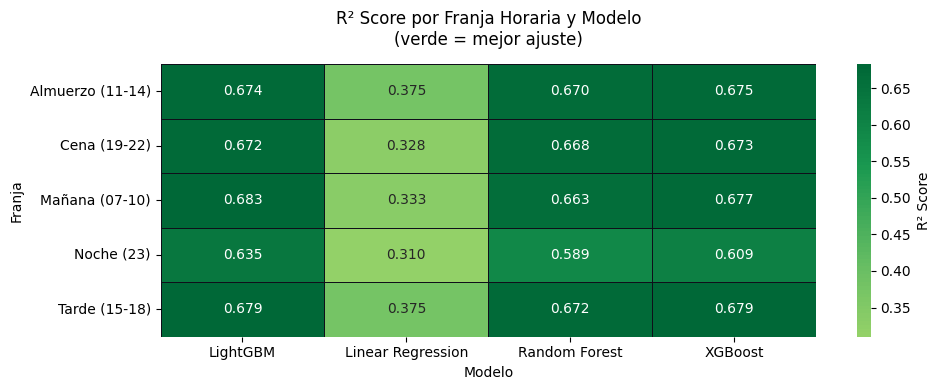

In [ ]:
# ── HEATMAP DE R² POR FRANJA ──────────────────────────────────────────────────
tabla_r2 = df_strat.pivot_table(
    index='Franja', columns='Modelo', values='R2'
).round(3)

plt.figure(figsize=(10, 4))
sns.heatmap(
    tabla_r2, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='#0f0f1a',
    cbar_kws={'label': 'R² Score'}
)
plt.title('R² Score por Franja Horaria y Modelo\n(verde = mejor ajuste)', pad=14)
plt.tight_layout()
plt.show()

La tabla R² por franja horaria muestra que LightGBM, XGBoost y Random Forest superan a la Regresión Lineal, explicando mejor la variabilidad del ETA en todas las franjas, especialmente en horas punta. LightGBM y XGBoost ofrecen el mejor ajuste.

In [ ]:
# ── CONFORMAL PREDICTION ESTRATIFICADA ───────────────────────────────────────
# ¿El ancho del intervalo varía según la franja? (debería ser mayor en hora punta)
registros_cp = []
for slot_id in sorted(SLOT_LABELS.keys()):
    mask = test_slots == slot_id
    if mask.sum() < 10:
        continue
    y_slot   = y_test_arr[mask]
    lo80_s   = lower_80[mask]; hi80_s = upper_80[mask]
    lo95_s   = lower_95[mask]; hi95_s = upper_95[mask]
    registros_cp.append({
        'Franja':       SLOT_LABELS[slot_id],
        'Cobertura_80': ((y_slot >= lo80_s) & (y_slot <= hi80_s)).mean(),
        'Cobertura_95': ((y_slot >= lo95_s) & (y_slot <= hi95_s)).mean(),
        'Ancho_80':     (hi80_s - lo80_s).mean(),
        'Ancho_95':     (hi95_s - lo95_s).mean(),
        'N':            mask.sum()
    })

df_cp_strat = pd.DataFrame(registros_cp)
print('Conformal Prediction — Cobertura y ancho por franja:\n')
print(df_cp_strat.to_string(index=False, float_format='{:.2f}'.format))

Conformal Prediction — Cobertura y ancho por franja:

          Franja  Cobertura_80  Cobertura_95  Ancho_80  Ancho_95    N
  Mañana (07-10)          0.76          0.92     21.74     34.06 1395
Almuerzo (11-14)          0.80          0.95     21.74     34.06 4011
   Tarde (15-18)          0.81          0.95     21.74     34.06 3375
    Cena (19-22)          0.82          0.95     21.74     34.06 3781
      Noche (23)          0.76          0.93     21.74     34.06  153


## 8.5 Modelo usando característica "Saturación" directamente

En esta sección hemos decidido evaluar el comportamiento de los modelos con la característica de saturación sin ningún cálculo o derivación de otras features como se ha propuesto en la sección anterior donde se utilizan _live_orders_ y _live_couriers_.

Esto lo hemos realizado como una hipótesis que busca comparar como la creación de variables adicionales puede o no aportar a un modelo que tiene poca información, tomamos la variable de saturación como base ya que está muestra una correlación directa con el ETA.

Para ello hemos creado un grupo de features solo con la característica mencionada:

In [ ]:
# Preprocesar la data con features_finales_v2
# Primero, arreglar el typo en features_finales_v2 si existe
features_finales_v2_corrected = [
    'hour_of_day', 'day_of_week', 'is_weekend',
    'delivery_distance_km', 'total_items',
    'transport_type_num', 'store_historical_wait_time_min',
    'orders_in_5m_window', 'saturation',
    'is_batched', 'batch_position',
    'time_slot'
]

# Recrear el pipeline para asegurar que 'saturation' es tratado correctamente
pipeline_v2_corrected = Pipeline(steps=[
    ('extractor', GlovoFeatureExtractor()),
    ('cleaner',   GlovoOutlierCleaner()),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',    RobustScaler())
])

X_final_v2, y_final_v2 = get_processed_data(df, 'target_total_delivery_time_min', pipeline_v2_corrected, features_finales_v2_corrected)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_final_v2, y_final_v2, test_size=0.2, random_state=42
)

print(f'Dataset procesado con features_finales_v2: {X_final_v2.shape[0]:,} filas x {X_final_v2.shape[1]} features')
print(f'Train_v2: {X_train_v2.shape[0]:,} | Test_v2: {X_test_v2.shape[0]:,}')

Dataset procesado con features_finales_v2: 63,572 filas x 12 features
Train_v2: 50,857 | Test_v2: 12,715


### 8.5.1. Modelos con saturación directa

#### Regresión Lineal (Baseline) con features_finales_v2

In [ ]:
model_lr_v2 = LinearRegression()
model_lr_v2.fit(X_train_v2, y_train_v2)
y_pred_lr_v2 = model_lr_v2.predict(X_test_v2)

mae_lr_v2  = mean_absolute_error(y_test_v2, y_pred_lr_v2)
rmse_lr_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_lr_v2))
r2_lr_v2   = r2_score(y_test_v2, y_pred_lr_v2)
print(f'Linear Regression (v2) — MAE: {mae_lr_v2:.2f} | RMSE: {rmse_lr_v2:.2f} | R²: {r2_lr_v2:.3f}')

Linear Regression (v2) — MAE: 7.52 | RMSE: 9.29 | R²: 0.634


#### XGBoost con features_finales_v2

In [ ]:
model_xgb_v2 = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_xgb_v2.fit(X_train_v2, y_train_v2)
y_pred_xgb_v2 = model_xgb_v2.predict(X_test_v2)

mae_xgb_v2  = mean_absolute_error(y_test_v2, y_pred_xgb_v2)
rmse_xgb_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb_v2))
r2_xgb_v2   = r2_score(y_test_v2, y_pred_xgb_v2)
print(f'XGBoost (v2) — MAE: {mae_xgb_v2:.2f} | RMSE: {rmse_xgb_v2:.2f} | R²: {r2_xgb_v2:.3f}')

XGBoost (v2) — MAE: 6.86 | RMSE: 8.61 | R²: 0.686


#### Random Forest con features_finales_v2

In [ ]:
model_rf_v2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model_rf_v2.fit(X_train_v2, y_train_v2)
y_pred_rf_v2 = model_rf_v2.predict(X_test_v2)

mae_rf_v2  = mean_absolute_error(y_test_v2, y_pred_rf_v2)
rmse_rf_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_rf_v2))
r2_rf_v2   = r2_score(y_test_v2, y_pred_rf_v2)
print(f'Random Forest (v2) — MAE: {mae_rf_v2:.2f} | RMSE: {rmse_rf_v2:.2f} | R²: {r2_rf_v2:.3f}')

Random Forest (v2) — MAE: 6.90 | RMSE: 8.64 | R²: 0.683


#### LightGBM con features_finales_v2

In [ ]:
model_lgb_v2 = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model_lgb_v2.fit(X_train_v2, y_train_v2)
y_pred_lgb_v2 = model_lgb_v2.predict(X_test_v2)

mae_lgb_v2  = mean_absolute_error(y_test_v2, y_pred_lgb_v2)
rmse_lgb_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_lgb_v2))
r2_lgb_v2   = r2_score(y_test_v2, y_pred_lgb_v2)
print(f'LightGBM (v2) — MAE: {mae_lgb_v2:.2f} | RMSE: {rmse_lgb_v2:.2f} | R²: {r2_lgb_v2:.3f}')

LightGBM (v2) — MAE: 6.85 | RMSE: 8.60 | R²: 0.687


#### Resumen de Modelos con features_finales_v2

In [ ]:
print('══ COMPARACIÓN DE MODELOS (v1 vs v2) ══════')

# Define resumen_v2 DataFrame
resumen_v2 = pd.DataFrame({
    'Modelo': ['Linear Regression (v2)', 'Random Forest (v2)', 'XGBoost (v2)', 'LightGBM (v2)'],
    'MAE (min)':  [mae_lr_v2, mae_rf_v2, mae_xgb_v2, mae_lgb_v2],
    'RMSE (min)': [rmse_lr_v2, rmse_rf_v2, rmse_xgb_v2, rmse_lgb_v2],
    'R²':         [r2_lr_v2, r2_rf_v2, r2_xgb_v2, r2_lgb_v2]
})

# Format the numerical columns to string with desired precision
resumen_v2['MAE (min)']  = resumen_v2['MAE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen_v2['RMSE (min)'] = resumen_v2['RMSE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen_v2['R²']         = resumen_v2['R²'].apply(lambda x: f'{x:.3f}' if isinstance(x, float) else x)

# Define resumen DataFrame (moved from cell -JDwb9A2nkz2)
resumen = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE (min)':  [mae_lr, mae_rf, mae_xgb, mae_lgb],
    'RMSE (min)': [rmse_lr, rmse_rf, rmse_xgb, rmse_lgb],
    'R²':         [r2_lr, r2_rf, r2_xgb, r2_lgb]
})

resumen['MAE (min)']  = resumen['MAE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen['RMSE (min)'] = resumen['RMSE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen['R²']         = resumen['R²'].apply(lambda x: f'{x:.3f}' if isinstance(x, float) else x)

resumen_comparativo = pd.concat([resumen, resumen_v2], ignore_index=True)

print(resumen_comparativo.to_string(index=False))

══ COMPARACIÓN DE MODELOS (v1 vs v2) ══════
                Modelo MAE (min) RMSE (min)    R²
     Linear Regression      9.21      12.28 0.360
         Random Forest      6.98       8.82 0.670
               XGBoost      6.91       8.72 0.678
              LightGBM      6.91       8.72 0.678
Linear Regression (v2)      7.52       9.29 0.634
    Random Forest (v2)      6.90       8.64 0.683
          XGBoost (v2)      6.86       8.61 0.686
         LightGBM (v2)      6.85       8.60 0.687


Para todos los modelos de ensemble, la introducción de las características de la versión 2 resultó en una ligera, pero consistente, mejora en todas las métricas.

Los modelos LightGBM (v2) y XGBoost (v2) demuestran un rendimiento mejor en relación a sus comparaciones. LightGBM (v2) se destaca ligeramente con el menor MAE (6.85) y el mayor R² (0.687), lo que lo posiciona como la opción más precisa y robusta para este problema de predicción de ETA. La incorporación de las características la versión 2 fue un éxito, mejorando la capacidad predictiva general de todos los modelos.



### 8.5.2. Cross-Validation del modelo LightGBM (v2)

In [ ]:
import plotly.graph_objs as go
import plotly.express as px

modelos_v2 = {
    'LightGBM (v2)': model_lgb_v2
}

resultados_cv_v2 = {}
print('\n── Cross-Validation (5-Fold, MAE, RMSE, R²) para LightGBM (v2) ───')
for name, model in modelos_v2.items():
    scores_mae_v2 = cross_val_score(
        model, X_final_v2, y_final_v2,
        cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    scores_rmse_v2 = cross_val_score(
        model, X_final_v2, y_final_v2,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    scores_r2_v2 = cross_val_score(
        model, X_final_v2, y_final_v2,
        cv=kf, scoring='r2', n_jobs=-1
    )

    mae_mean_v2 = -scores_mae_v2.mean()
    mae_std_v2  = scores_mae_v2.std()

    rmse_mean_v2 = -scores_rmse_v2.mean()
    rmse_std_v2  = scores_rmse_v2.std()

    r2_mean_v2 = scores_r2_v2.mean()
    r2_std_v2  = scores_r2_v2.std()

    resultados_cv_v2[name] = {
        'mae': mae_mean_v2, 'mae_std': mae_std_v2,
        'rmse': rmse_mean_v2, 'rmse_std': rmse_std_v2,
        'r2': r2_mean_v2, 'r2_std': r2_std_v2
    }
    print(f'  {name:<22}  MAE = {mae_mean_v2:.3f} (±{mae_std_v2:.3f})')
    print(f'  {name:<22}  RMSE = {rmse_mean_v2:.3f} (±{rmse_std_v2:.3f})')
    print(f'  {name:<22}  R² = {r2_mean_v2:.3f} (±{r2_std_v2:.3f})')

# Puedes acceder a los resultados así:
# mae_lgbm_v2 = resultados_cv_v2['LightGBM (v2)']['mae']
# rmse_lgbm_v2 = resultados_cv_v2['LightGBM (v2)']['rmse']
# r2_lgbm_v2 = resultados_cv_v2['LightGBM (v2)']['r2']


── Cross-Validation (5-Fold, MAE, RMSE, R²) para LightGBM (v2) ───
  LightGBM (v2)           MAE = 6.909 (±0.037)
  LightGBM (v2)           RMSE = 8.661 (±0.047)
  LightGBM (v2)           R² = 0.693 (±0.005)


El modelo **LightGBM (v2)**, que incorpora directamente la característica `saturation`, muestra una ligera pero consistente mejora en su rendimiento en comparación con el **LightGBM (v1)**, que utilizaba `live_orders` y `live_couriers` como aproximaciones de la saturación, **basándose en los resultados de la validación cruzada (5-Fold)**.

**Comparativa de métricas de Validación Cruzada:**

| Modelo         | MAE CV (min) | RMSE CV (min) | R² CV |
| :------------- | :----------- | :------------ | :---- |
| LightGBM (v1)  | 6.978        | 8.783         | 0.684  |
| LightGBM (v2)  | 6.909        | 8.661         | 0.693 |

El modelo **LightGBM (v2)** mejora el rendimiento general en la validación cruzada, ofreciendo predicciones más precisas y una mayor capacidad explicativa. Esto valida la hipótesis de que utilizar la característica de saturación de manera directa en lugar de sus derivaciones contribuye positivamente a la capacidad del modelo para predecir el ETA.

### 8.5.3. Importancia de Features del modelo LightGBM (v2)

In [ ]:
importances_lgb_v2 = model_lgb_v2.feature_importances_

df_imp_v2 = pd.DataFrame({
    'Feature': features_finales_v2_corrected,
    'LightGBM (v2)': importances_lgb_v2 / importances_lgb_v2.sum()
}).sort_values('LightGBM (v2)', ascending=True)

fig_imp_v2 = px.bar(
    df_imp_v2,
    x='LightGBM (v2)',
    y='Feature',
    orientation='h',
    title='Importancia de Features — LightGBM (v2)',
    labels={'LightGBM (v2)': 'Importancia relativa (normalizada)', 'Feature': 'Característica'},
    color_discrete_sequence=['#4da8da']
)
fig_imp_v2.update_layout(
    template='plotly_dark',
    paper_bgcolor='#0f0f1a',
    plot_bgcolor='#1a1a2e',
    height=550,
    yaxis={'categoryorder':'total ascending'}
)
fig_imp_v2.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Definición de color (Teal de la imagen de referencia)
color_teal = '#108e71'

# 2. Preparación de datos v2
importances_lgb_v2 = model_lgb_v2.feature_importances_

df_imp_v2 = pd.DataFrame({
    'Feature': features_finales_v2_corrected,
    'LightGBM (v2)': importances_lgb_v2 / importances_lgb_v2.sum()
})

# Filtrar solo el Top 5
df_top5_v2 = df_imp_v2.nlargest(5, 'LightGBM (v2)').sort_values('LightGBM (v2)', ascending=True)

# 3. Creación del gráfico
fig_imp_v2 = go.Figure()

fig_imp_v2.add_trace(go.Bar(
    y=df_top5_v2['Feature'],
    x=df_top5_v2['LightGBM (v2)'],
    orientation='h',
    name='LightGBM v2',
    marker_color=color_teal,
    # Añadimos el texto del porcentaje dentro de la barra para que sea como la imagen
    text=(df_top5_v2['LightGBM (v2)'] * 100).round(1).astype(str) + '%',
    textposition='auto'
))

# 4. Formato y Estilo Completo
fig_imp_v2.update_layout(
    title='Top 5 Importancia de Features — LightGBM (v2)',
    xaxis_title='Importancia relativa (normalizada)',
    template='plotly_white',
    height=400,
    width=900,
    font=dict(family="Arial", size=14, color="black"),
    margin=dict(l=200),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Ajuste de la rejilla
fig_imp_v2.update_xaxes(showgrid=True, gridcolor='lightgray')
fig_imp_v2.update_yaxes(showgrid=False)

fig_imp_v2.show()

# 9. Conclusiones

## 9.1. Conclusiones generales

El objetivo era construir un modelo de inteligencia artificial capaz de predecir el tiempo total que tarda un pedido de Glovo en llegar al cliente (ETA) en la ciudad de París. Saber este tiempo con antelación es valioso tanto para informar al cliente como para optimizar la operación logística.

Antes de entrenar cualquier modelo, tuvimos que explorar y limpiar el dataset, y luego construir variables nuevas más informativas. Este proceso se llama feature engineering y es clave para que el modelo aprenda bien.
* Batching
* Demanda en tiempo real
* Distancia Haversine
* Franja horaria
* Historial de tienda
* Limpieza de outliers

Modelos:

Se entrenaron 4 modelos con las mismas 13 variables y se evaluaron con tres métricas: el MAE (error promedio en minutos), el RMSE (penaliza más los errores grandes) y el R² (qué porcentaje de la variabilidad del ETA explica el modelo).

| Modelo | MAE | RMSE | R² |
| :--- | :--- | :--- | :--- |
| Regresión Lineal (baseline) | 10,35 min | 13,93 min | 0,36 |
| Random Forest | 6,98 min | 8,82 min | 0,670 |
| XGBoost | 6,91 min | 8,72 min | 0,678 |
| LightGBM (ganador) | 6,91 min | 8,72 min | 0,678 |

Resultados clave:
1. La regresión lineal no es adecuada para este problema

    Con un R² de solo 0,36, explica únicamente el 36% de la variación en los tiempos. El análisis de residuos confirmó que la relación no es lineal: a mayor predicción, mayor error. Este modelo es útil como punto de partida (baseline) pero no para producción.

2. Los modelos de árboles capturan la complejidad real del problema

    XGBoost, Random Forest y LightGBM bajaron el error de 10,35 a 6,91 minutos, más del 33%. Esto confirma que las relaciones entre las variables y el ETA son no lineales y los árboles de decisión los capturan de forma natural.

3. LightGBM es el más eficiente

    Ambos (LGBM y XGB) obtienen exactamente el mismo MAE (6,91) y R² (0,678). La diferencia está en la velocidad donde LightGBM usa un algoritmo basado en histogramas que es hasta 20 veces más rápido con datasets grandes como este (~63k filas). En producción, ese tiempo importa.


El modelo recomendado sería LightGBM con Conformal Prediction. Iguala la precisión de XGBoost en todas las métricas (MAE 6,91 min, R² 0,678) pero es mucho más rápido de entrenar y predecir, lo que es crítico en un sistema de tiempo real como el ETA de una app de delivery

In [ ]:
# ── TABLA COMPARATIVA GLOBAL ──────────────────────────────────────────────────
resumen = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE (min)':  [mae_lr, mae_rf, mae_xgb, mae_lgb],
    'RMSE (min)': [rmse_lr, rmse_rf, rmse_xgb, rmse_lgb],
    'R²':         [r2_lr, r2_rf, r2_xgb, r2_lgb]
})

resumen['MAE (min)']  = resumen['MAE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen['RMSE (min)'] = resumen['RMSE (min)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
resumen['R²']         = resumen['R²'].apply(lambda x: f'{x:.3f}' if isinstance(x, float) else x)

print('\n══ RESUMEN DE MODELOS ══════')
print(resumen.to_string(index=False))


══ RESUMEN DE MODELOS ══════
           Modelo MAE (min) RMSE (min)    R²
Linear Regression      9.21      12.28 0.360
    Random Forest      6.98       8.82 0.670
          XGBoost      6.91       8.72 0.678
         LightGBM      6.91       8.72 0.678


## 9.2. Resumen de Modelos con Features v2 y Comparativa

### 1. Resultados de los modelos con la versión 2 de características (8.5.1):

La introducción de la característica `saturation` directamente (versión 2 de features) ha mostrado una mejora consistente en el rendimiento de los modelos en comparación con la versión 1.

| Modelo                 | MAE (min) | RMSE (min) | R²    |
| :--------------------- | :-------- | :--------- | :---- |
| Linear Regression (v2) | 7.52      | 9.29       | 0.634 |
| Random Forest (v2)     | 6.90      | 8.64       | 0.683 |
| XGBoost (v2)           | 6.86      | 8.61       | 0.686 |
| LightGBM (v2)          | 6.85      | 8.60       | 0.687 |

El modelo LightGBM (v2) se destaca como el de mejor rendimiento, logrando el menor MAE y el mayor R². Sin embargo no representa un cambio significativo a relación de la (v1)

### 2. Resultados de Cross-Validation para LightGBM (v2):

La validación cruzada 5-Fold para LightGBM (v2) confirma su robustez y precisión:

*   **MAE:** 6.909 (±0.037) min
*   **RMSE:** 8.661 (±0.047) min
*   **R²:** 0.693 (±0.005)

Estos resultados son muy consistentes y demuestran la fiabilidad del modelo. Sin embargo no se ve una mejora significativa al modelo propuesto de la (v1)

### 3. Top 5 Features más importantes para LightGBM (v2):

Las características más influyentes para el modelo LightGBM (v2) son:

1.  **delivery_distance_km**: 0.203
2.  **store_historical_wait_time_min**: 0.190
3.  **saturation**: 0.189
4.  **hour_of_day**: 0.107
5.  **total_items**: 0.085

### 4. Resumen comparativo con LightGBM principal (v1):

La incorporación directa de la característica `saturation` en la versión 2 de los features ha resultado en una mejora tangible en el rendimiento general del modelo LightGBM. Consideramos que las features del modelo (v1) podría tener mejores resultados con features que complementen o se correlacionen mejor y apaorten mayor información de los pedidos.

# 10. Recomendaciones

#### *Gridsearch*
Inicialmente se quería realizar un proceso de Gridsearch, pero al evaluar que el modelo ya alcanzó un R² de 0,678, significaba que el 67,8% de la variación en los tiempos de entrega ya está siendo contemplada. El 32,2% restante que el modelo no puede capturar proviene principalmente de:

#### *Separación del modelo*
Se podría complementar el estudio con un análisis particiondado de los datos, actualemente los modelos se centran en tiempos promdeio de 30 a 40 min.

#### *Ensamble de modelos*
Se podría generar un ensable de modelos ya que tenemos ambos propuestas con valores parejos (LightGMB y XGBoost), esto podría generar un MAE mucho menor.

### *Robustecer el conjunto de datos y features*
Se requieren más variables que puedan aportar mayor valor a la variable objetivo, se sugiere tener en consideración variables como:

*   Tráfico en tiempo real
*   Información más detallada de la saturación
*   Tiempo de preparación en tienda
*   Características del área de entrega

### *Bias*
Se puede añadir un *bias* al tiempo de predicción, generando un "colchón" dentro del estimado del tiempo como estrategia de mercado. Un cliente se puede ver mayormente contento sabiendo que su orden con un ETA de 30 min, realmente tomó 25 min. o menos.

### *CV*
CV: La configuración de *cross-validation* puede modificarse, los valores usados tomaron tiempo en calcularse, pero esto depende del cómputo y configuración.

### *Saturación*
`saturation`: Hace falta definición de la saturación y explicación del cálculo detrás de la variable, tener escala de 20 a 239 es algo anormal o al menos no es una escala del 0 al 100%.

### *Tiempo*
Tiempo: De existir la temperatura y el clima que existió en ese día, podría ayudar a mejorar el modelo.

### *Temporalidad*
Dataset con 90 días: Al ser un dataset de 90 días no existen patrones de estacionalidad, de los cuales pueden afectar a un ETA.

### *Distancia*
Distancia: La distancia fue calculada a través de un método que no toma calles o sentido de circulación, es una simple línea recta; que aunada al factor de trayectoria genera una **aproximación**. Se podría utilizar una API de OpenStreet Maps o Google Maps.


# Puntos de mejora

1. Fugas de Datos (Target Leakage)

Existe una parte de las features generadas que no están correctamente elaboradas, tal es el caso de la saturación; dado que la saturación no tiene una escala del 0 al 100%, como se ha mencionado previamente, se generan porcentajes que realmente no muestran de poca a mucha saturación.

Variable is_batched: Se calculó utilizando el tiempo real de entrega (delivery_time_local), que es exactamente lo que el modelo intenta predecir. En la vida real, al momento en que un cliente hace un pedido, el modelo no sabe a qué hora se entregará.

Variable store_historical_wait_time_min: Se calculó el tiempo promedio de espera de los restaurantes usando todo el dataset antes de dividirlo. Esto significa que el modelo de entrenamiento aprendió promedios que incluyen datos del futuro (del conjunto de prueba).

2. Errores de Preprocesamiento

Contaminación en el escalado e imputación: Se aplicó fit_transform (para rellenar nulos y escalar datos) a todo el dataset antes de hacer el train_test_split.
Mal uso de Pipelines: Se usaron los pasos del Pipeline de Scikit-Learn de forma manual para poder eliminar filas.

3. Fallos de Lógica de Negocio y Modelado

Variables de tiempo mal tratadas: La hora del día (0-23) y el día de la semana (0-6) se introdujeron como números continuos en lugar de categorías. El modelo lineal asume erróneamente que el domingo (6) vale numéricamente más que el lunes (0).

Mirando al futuro en tiempo real: La variable de volumen de pedidos en 5 minutos (orders_in_5m_window) se redondeó hacia adelante, contando pedidos que aún no habían ocurrido en el momento exacto de la compra.

Variables no disponibles en producción: Se incluyó el tipo de vehículo del repartidor para predecir el tiempo de entrega al momento del checkout. En ese momento, el sistema de Glovo aún no ha asignado un repartidor ni sabe qué vehículo usará.

Hizo falta mayor EDA respecto al ETA creado y a la saturación para tener un mejor feature engineering. Se realizaron dos trabajos en conjunto y por mayoría se decidió este a pesar de sus debilidades pero que hacen un modelo que corrobora la alta correlación de la saturación con el tiempo que tarda un pedido en llegar.




